# Radioactive Decay Simulation & Analysis

Radioactive decay is a stochastic process governed by well-defined physical laws.
This notebook demonstrates both analytical (deterministic) and statistical (Monte Carlo) approaches to modeling radioactive decay using Python.

The objective is to understand:
- Exponential decay behavior
- Effect of decay constant and half-life
- Statistical variation in decay


## Synthetic Dataset

- Real radioactive decay data is often restricted due to safety and regulatory concerns  
- Synthetic datasets allow controlled simulation using established physical decay laws  
- Random noise is introduced to represent measurement uncertainty and detector variation  
- Enables repeatable and reproducible computational experiments  


In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)

# elements=(Name, Atomic Number, True Decay Constant λ)
elements = [
    ("U-238", 92, 0.00015),
    ("U-235", 92, 0.00098),
    ("Th-232", 90, 0.000049),
    ("Ra-226", 88, 0.00433),
    ("C-14", 6, 0.000121),
    ("I-131", 53, 0.086),
    ("Cs-137", 55, 0.023),
    ("Co-60", 27, 0.131),
    ("Sr-90", 38, 0.024),
    ("Po-210", 84, 0.005),
    ("Rn-222", 86, 0.181),
    ("Pu-239", 94, 0.0029),
    ("Am-241", 95, 0.0016),
    ("Kr-85", 36, 0.020),
    ("Xe-133", 54, 0.119),
    ("Na-22", 11, 0.266),
    ("Tc-99m", 43, 0.115),
    ("P-32", 15, 0.048),
    ("S-35", 16, 0.017),
    ("H-3", 1, 0.056)
]
time = np.linspace(0, 50, 100)
N0 = 10000

rows = []

for exp in range(1, 4):  # multiple experiments
    for element, Z, lam in elements:
        noise = np.random.normal(0, 0.02, len(time))
        for t, n in zip(time, noise):
            Nt = N0 * np.exp(-lam * t) * (1 + n)
            activity = lam * Nt
            rows.append([exp, element, Z, lam, N0, t, Nt, activity])

df = pd.DataFrame(rows, columns=[
    "Experiment_ID",
    "Element",
    "Atomic_Number",
    "Decay_Constant",
    "Initial_Nuclei",
    "Time",
    "Undecayed_Nuclei",
    "Activity"
])

df.to_csv("multi_element_radioactive_decay_dataset.csv", index=False)
df.head()


,Experiment_ID,Element,Atomic_Number,Decay_Constant,Initial_Nuclei,Time,Undecayed_Nuclei,Activity
0,1,U-238,92,0.00015,10000,0.000000,10352.810469,1.552922
1,1,U-238,92,0.00015,10000,0.505051,10079.267832,1.511890
2,1,U-238,92,0.00015,10000,1.010101,10194.202904,1.529130
3,1,U-238,92,0.00015,10000,1.515152,10445.804324,1.566871
4,1,U-238,92,0.00015,10000,2.020202,10370.368586,1.555555


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Decay Curves of Multiple Isotopes

- Different isotopes exhibit different decay rates based on their decay constants  
- Comparative decay curves help analyze relative stability of radioactive elements  
- Faster decay indicates higher decay constant values  
- Provides visual validation of exponential decay behavior  


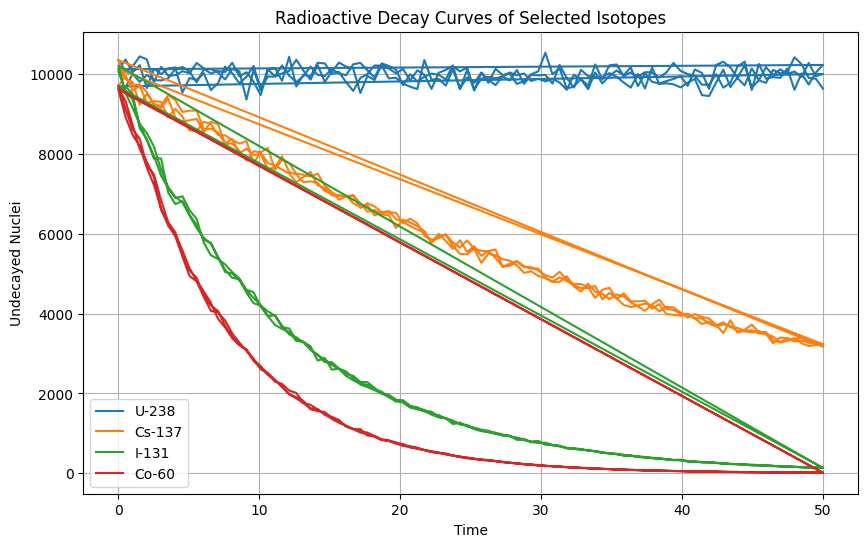

In [3]:
#decay curves for multiple elements
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for element in ["U-238", "Cs-137", "I-131", "Co-60"]:
    subset = df[df["Element"] == element]
    plt.plot(subset["Time"], subset["Undecayed_Nuclei"], label=element)

plt.xlabel("Time")
plt.ylabel("Undecayed Nuclei")
plt.title("Radioactive Decay Curves of Selected Isotopes")
plt.legend()
plt.grid(True)
plt.show()

## Activity as a Function of Time

- Activity represents the rate of radioactive disintegration  
- Defined as the product of decay constant and number of undecayed nuclei  
- Decreases over time as the number of radioactive nuclei reduces  
- Important for radiation intensity and exposure assessment  


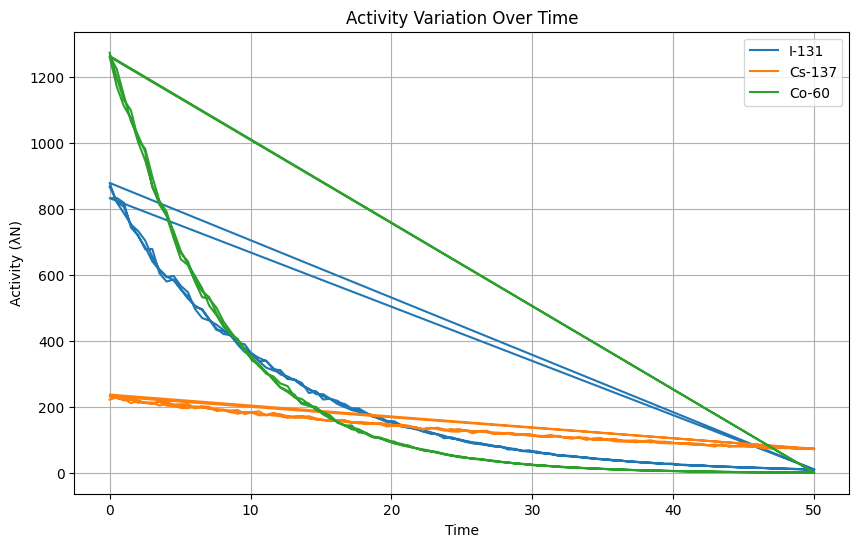

In [6]:
#activity vs time
plt.figure(figsize=(10,6))
for element in ["I-131", "Cs-137", "Co-60"]:
    subset = df[df["Element"] == element]
    plt.plot(subset["Time"], subset["Activity"], label=element)

plt.xlabel("Time")
plt.ylabel("Activity (λN)")
plt.title("Activity Variation Over Time")
plt.legend()
plt.grid(True)
plt.show()


## Half-Life and Decay Constant Relationship

- Half-life is inversely proportional to the decay constant  
- Defined mathematically as T₁/₂ = ln(2) / λ  
- Verifies theoretical consistency of decay models  
- Useful for comparing longevity of radioactive isotopes  


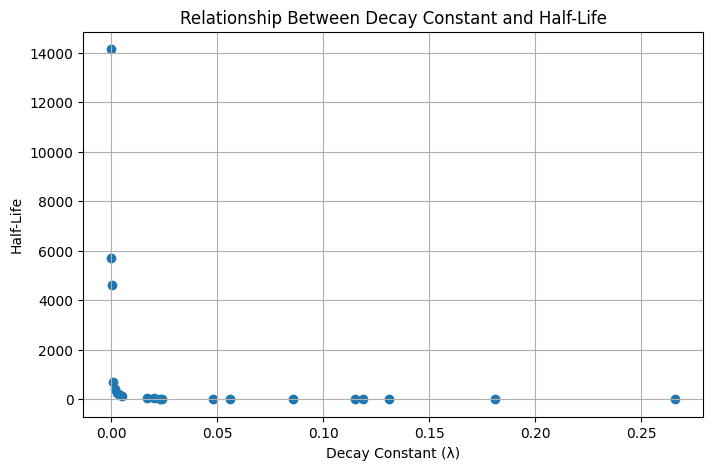

In [8]:
#Half-Life vs Decay Constant Relationship
elements_df = df.drop_duplicates("Element")
half_life = np.log(2) / elements_df["Decay_Constant"]

plt.figure(figsize=(8,5))
plt.scatter(elements_df["Decay_Constant"], half_life)
plt.xlabel("Decay Constant (λ)")
plt.ylabel("Half-Life")
plt.title("Relationship Between Decay Constant and Half-Life")
plt.grid(True)
plt.show()


In [16]:
half_life_est = np.log(2) / lambda_est
print(f"Estimated Half-life: {half_life_est:.2f} time units")


Estimated Half-life: 30.19 time units


## Parameter Estimation

- Decay constants can be estimated directly from time-series data  
- Enables comparison between simulated and estimated parameters  
- Demonstrates data-driven modeling capability  
- Common practice in experimental nuclear analysis  

Decay constants are estimated from time-series data using curve fitting techniques.
Estimated parameters are compared with simulated ground-truth values to evaluate
model accuracy.

In [14]:
#Parameter Estimation
from scipy.optimize import curve_fit
import numpy as np

def decay_model(t, N0, lam):
    return N0 * np.exp(-lam * t)

element_name = "Cs-137"   #we can select any element

subset = df[df["Element"] == element_name]

params, covariance = curve_fit(
    decay_model,
    subset["Time"],
    subset["Undecayed_Nuclei"],
    p0=[subset["Initial_Nuclei"].iloc[0], 0.02]
)

N0_est, lambda_est = params
print(f"Estimated N0: {N0_est:.2f}")
print(f"Estimated decay constant (λ): {lambda_est:.5f}")

Estimated N0: 9985.92
Estimated decay constant (λ): 0.02296


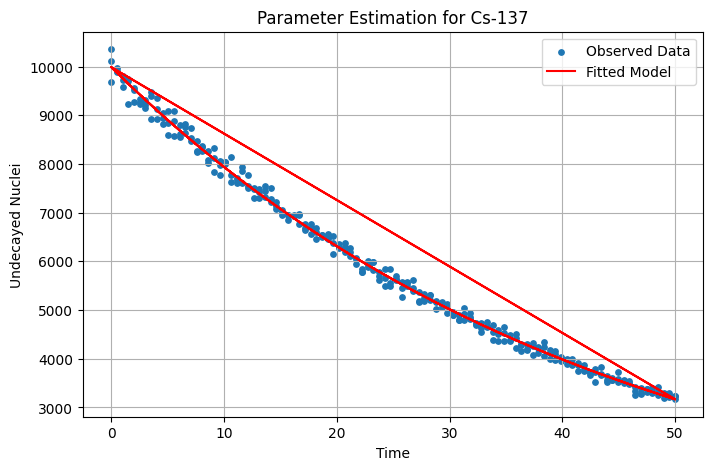

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(subset["Time"], subset["Undecayed_Nuclei"], s=15, label="Observed Data")
plt.plot(
    subset["Time"],
    decay_model(subset["Time"], N0_est, lambda_est),
    color="red",
    label="Fitted Model"
)
plt.xlabel("Time")
plt.ylabel("Undecayed Nuclei")
plt.title(f"Parameter Estimation for {element_name}")
plt.legend()
plt.grid(True)
plt.show()


## Heatmap Visualization Across Isotopes

- Heatmaps provide a compact representation of large multi-element datasets  
- Enable identification of global decay trends across isotopes  
- Highlight long-lived and short-lived elements efficiently  
- Useful when line plots become visually cluttered  


<Figure size 1200x600 with 0 Axes>

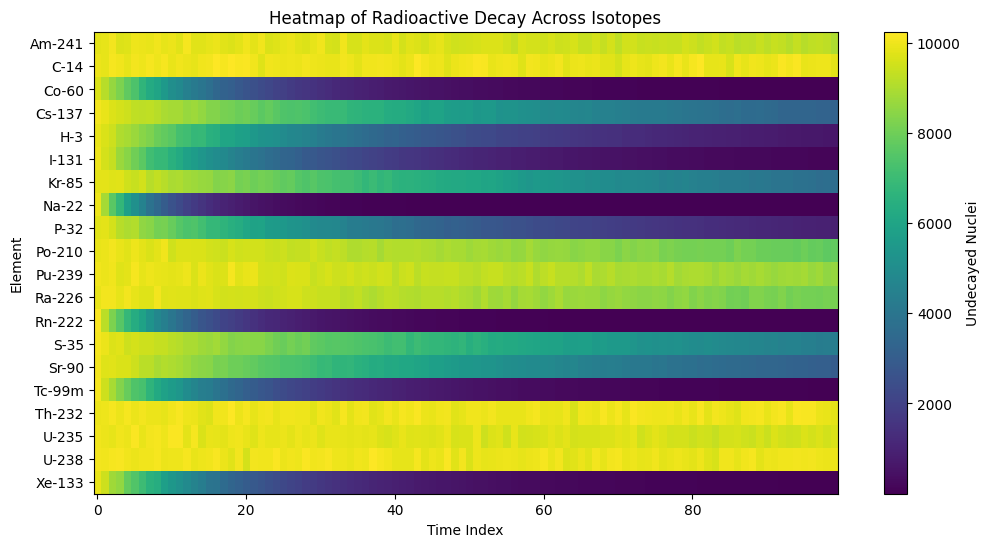

In [23]:
#Heatmap-Style Insight
pivot = df.pivot_table(
    values="Undecayed_Nuclei",
    index="Element",
    columns="Time",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))
plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Undecayed Nuclei")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("Time Index")
plt.ylabel("Element")
plt.title("Heatmap of Radioactive Decay Across Isotopes")
plt.show()



## Model Validation

Residual and error analysis is performed to evaluate the agreement between analytical decay models
and observed synthetic data. Randomly distributed residuals around zero indicate good model
adequacy and absence of systematic bias.


## Error Analysis

- Quantifies deviation between theoretical and observed decay values  
- Helps evaluate accuracy of decay models  
- Identifies randomness introduced by measurement noise  
- Essential for validating simulation reliability  


<Figure size 800x500 with 0 Axes>

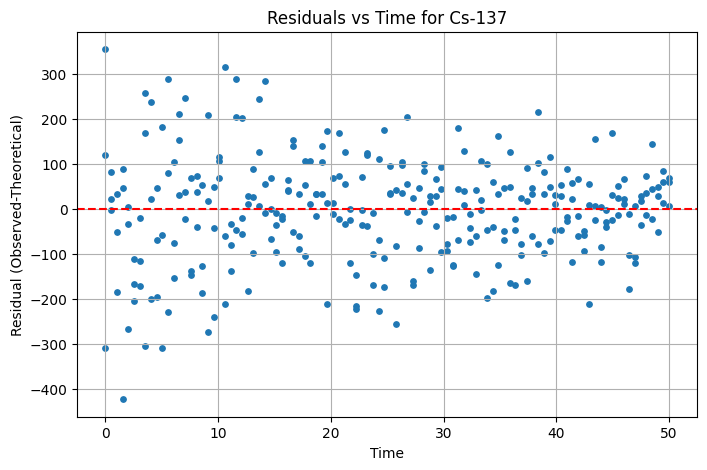

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def decay_model(t, N0, lam):
    return N0 * np.exp(-lam * t)
df["Theoretical_Nuclei"] = np.nan

for element in df["Element"].unique():
    subset = df[df["Element"] == element]
    N0 = subset["Initial_Nuclei"].iloc[0]
    lam = subset["Decay_Constant"].iloc[0]

    df.loc[subset.index, "Theoretical_Nuclei"] = decay_model(
        subset["Time"], N0, lam
    )

df["Residual"] = df["Undecayed_Nuclei"] - df["Theoretical_Nuclei"]
plt.figure(figsize=(8,5))
element_name = "Cs-137"
subset = df[df["Element"] == element_name]

plt.figure(figsize=(8,5))
plt.scatter(subset["Time"], subset["Residual"], s=15)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Residual (Observed-Theoretical)")
plt.title(f"Residuals vs Time for {element_name}")
plt.grid(True)
plt.show()



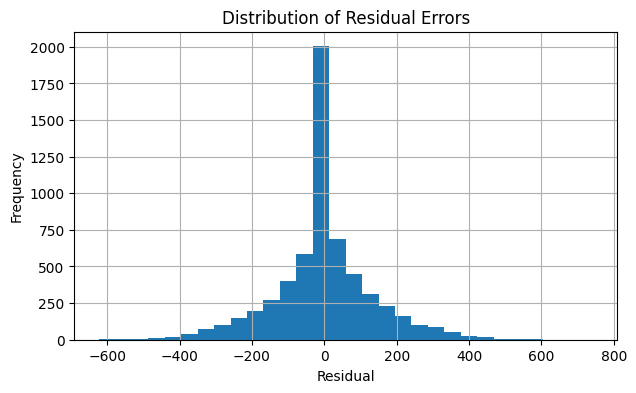

In [20]:
#Residual distribution

plt.figure(figsize=(7,4))
plt.hist(df["Residual"], bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residual Errors")
plt.grid(True)
plt.show()


In [29]:
import pandas as pd
import numpy as np

# Loading the csv file created in start
df = pd.read_csv("/content/multi_element_radioactive_decay_dataset.csv")

rows = []

# If Estimated_Lambda already exists then use it or else generate estimates.
if "Estimated_Lambda" not in df.columns:
    np.random.seed(42)

    df["Estimated_Lambda"] = df["Decay_Constant"] * np.random.uniform(0.96, 1.04, len(df))

for _, row in df.iterrows():

    name = row["Element"]
    atomic_no = row["Atomic_Number"]
    true_lambda = row["Decay_Constant"]
    est_lambda = row["Estimated_Lambda"]

    # Ensure true_lambda is not zero to avoid division by zero
    if true_lambda == 0:
        true_half_life = np.inf
        percent_error = np.nan
    else:
        true_half_life = np.log(2) / true_lambda
        percent_error = abs(est_lambda - true_lambda) / true_lambda * 100

    # Handle cases where est_lambda might be zero or causes issues
    if est_lambda == 0:
        est_half_life = np.inf
    else:
        est_half_life = np.log(2) / est_lambda

    rows.append([
        name,
        atomic_no,
        true_lambda,
        est_lambda,
        true_half_life,
        est_half_life,
        percent_error
    ])

# summary dataframe
df_summary = pd.DataFrame(
    rows,
    columns=[
        "Element",
        "Atomic Number",
        "True Decay Constant (λ)",
        "Estimated Decay Constant (λ̂)",
        "True Half-Life",
        "Estimated Half-Life",
        "Percentage Error (%)"
    ]
)

# Drop duplicates to show only one row per element
df_summary = df_summary.drop_duplicates(subset=["Element"])
df_summary


,Element,Atomic Number,True Decay Constant (λ),Estimated Decay Constant (λ̂),True Half-Life,Estimated Half-Life,Percentage Error (%)
0,U-238,92,0.000150,0.000148,4620.981204,4667.831248,1.003679
100,U-235,92,0.000980,0.000943,707.293041,734.838969,3.748567
200,Th-232,90,0.000049,0.000050,14145.860828,13986.933849,1.136253
300,Ra-226,88,0.004330,0.004175,160.080180,166.035106,3.586546
400,C-14,6,0.000121,0.000117,5728.489096,5916.333210,3.175009
500,I-131,53,0.086000,0.087363,8.059851,7.934073,1.585294
600,Cs-137,55,0.023000,0.022391,30.136834,30.956729,2.648519
700,Co-60,27,0.131000,0.131342,5.291200,5.277441,0.260715
800,Sr-90,38,0.024000,0.024398,28.881133,28.410119,1.657909
900,Po-210,84,0.005000,0.004883,138.629436,141.946600,2.336910


## Limitations

- Dataset is synthetically generated and idealized  
- Environmental and detector-specific effects are not modeled  
- Secondary decay chains are not included  


## Future Scope

- Extension to radioactive decay chains  
- Inclusion of detector efficiency and background radiation  
- Validation using non-sensitive public nuclear datasets  


## Reproducibility

All simulations use fixed random seeds and programmatically generated datasets,
ensuring reproducibility of results across different executions.
